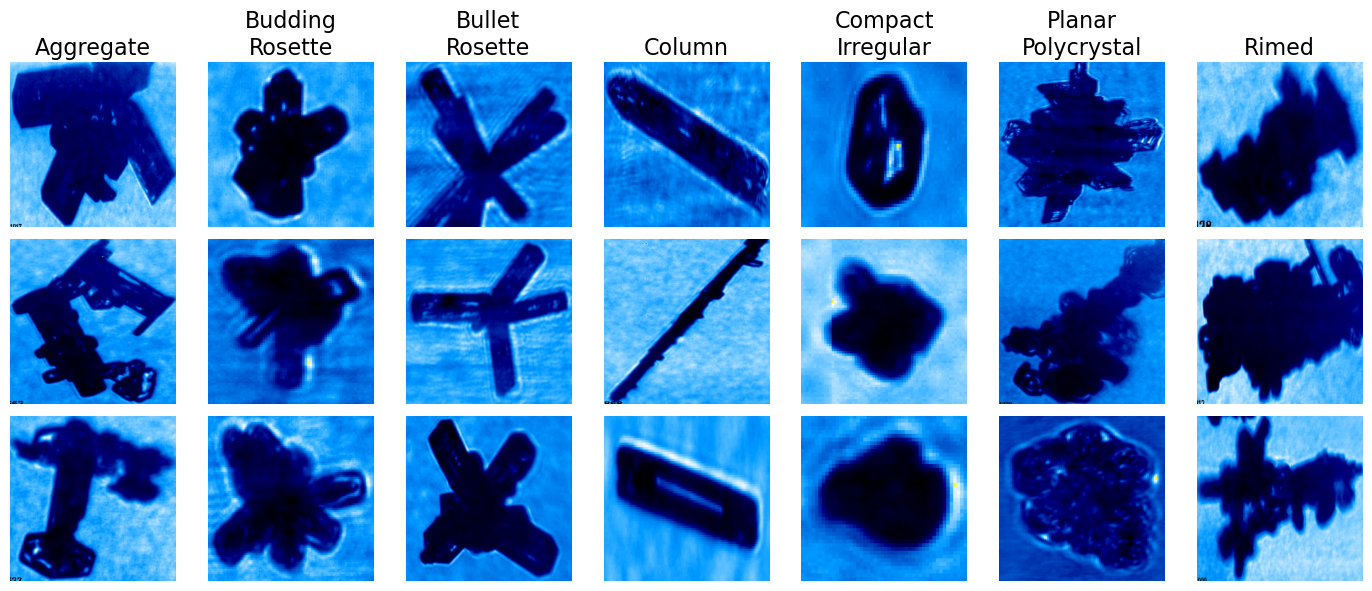

In [10]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

base_dir = '/home/vanessa/hulk/cocpit/cpi_data/training_datasets/v3.1.0/hand_labeled_noaug'
crystal_classes = [
    'agg', 'budding', 'bullet', 'column', 'compact_irreg', 'planar_polycrystal', 'rimed'
]  # You can change this list as needed
labels = ['Aggregate', 'Budding Rosette', 'Bullet Rosette', 'Column', 'Compact Irregular', 'Planar Polycrystal', 'Rimed']

n_rows = 3
n_cols = len(crystal_classes)

# Collect 3 random image paths from each class
image_grid = []  # This will be a list of 3 lists, each with n_cols images
for i in range(n_rows):
    row = []
    for cls in crystal_classes:
        folder = os.path.join(base_dir, cls)
        images = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        chosen = random.sample(images, n_rows)
        img = Image.open(os.path.join(folder, chosen[i]))
        row.append(img)
    image_grid.append(row)  # Each row has n_cols images

# Plot the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
for i in range(n_rows):
    for j in range(n_cols):
        axes[i, j].imshow(image_grid[i][j])
        axes[i, j].axis('off')
        if i == 0:
            # Split label on space for two-line titles
            title = labels[j].replace(' ', '\n')
            axes[i, j].set_title(title, fontsize=16)
plt.tight_layout()
plt.show()